In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import phoenix as px
import os
import json
from tqdm import tqdm
from phoenix.evals import (
    TOOL_CALLING_PROMPT_TEMPLATE, 
    llm_classify,
    OpenAIModel
)
from phoenix.trace import SpanEvaluations
from phoenix.trace.dsl import SpanQuery
from openinference.instrumentation import suppress_tracing

import nest_asyncio
nest_asyncio.apply()

In [3]:
from init_phoenix import init_phoenix
PROJECT_NAME = "evaluating-agent"

client, tool_calling_client, tracer = init_phoenix(project_name=PROJECT_NAME)

OpenTelemetry Tracing Details
|  Phoenix Project: evaluating-agent
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: http://localhost:6006/v1/traces
|  Transport: HTTP + protobuf
|  Transport Headers: {}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  WARNING: It is strongly advised to use a BatchSpanProcessor in production environments.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.



In [4]:
from tutorial1_code import Agent

In [5]:
agent = Agent(client, tool_calling_client, tracer)

In [ ]:
agent_questions = [
    "What was the most popular product SKU?",
    "What was the total revenue across all stores?",
    "Which store had the highest sales volume?",
    "Create a bar chart showing total sales by store",
    "What percentage of items were sold on promotion?",
    "What was the average transaction value?"
]

for question in tqdm(agent_questions, desc="Processing questions"):
    try:
        ret = agent.start_main_span([{"role": "user", "content": question}])
    except Exception as e:
        print(f"Error processing question: {question}")
        print(e)
        continue

In [ ]:
print(TOOL_CALLING_PROMPT_TEMPLATE)

In [6]:
query = SpanQuery().where(
    # Filter for the `LLM` span kind.
    # The filter condition is a string of valid Python boolean expression.
    "span_kind == 'LLM'",
).select(
    question="input.value",
    tool_call="llm.tools"
)

# The Phoenix Client can take this query and return the dataframe.
tool_calls_df = px.Client().query_spans(query, 
                                        project_name=PROJECT_NAME, 
                                        timeout=None)
tool_calls_df = tool_calls_df.dropna(subset=["tool_call"])


In [11]:

tool_calls_df["tool_call"].to_list()

[[{'tool': {'json_schema': '{"type": "function", "function": {"name": "lookup_sales_data", "description": "Look up data from Store Sales Price Elasticity Promotions dataset", "parameters": {"type": "object", "properties": {"prompt": {"type": "string", "description": "The unchanged prompt that the user provided."}}, "required": ["prompt"]}}}'}},
  {'tool': {'json_schema': '{"type": "function", "function": {"name": "analyze_sales_data", "description": "Analyze sales data to extract insights", "parameters": {"type": "object", "properties": {"data": {"type": "string", "description": "The lookup_sales_data tool\'s output."}, "prompt": {"type": "string", "description": "The unchanged prompt that the user provided."}}, "required": ["data", "prompt"]}}}'}},
  {'tool': {'json_schema': '{"type": "function", "function": {"name": "generate_visualization", "description": "Generate Python code to create data visualizations", "parameters": {"type": "object", "properties": {"data": {"type": "string", 

In [8]:
with suppress_tracing():
    tool_call_eval = llm_classify(
        dataframe = tool_calls_df,
        template = TOOL_CALLING_PROMPT_TEMPLATE.template[0].template.replace("{tool_definitions}", 
                                                                 json.dumps(agent.tools).replace("{", '"').replace("}", '"')),
        rails = ['correct', 'incorrect'],
        model=OpenAIModel(model="gpt-4o"),
        provide_explanation=True
    )

tool_call_eval['score'] = tool_call_eval.apply(lambda x: 1 if x['label']=='correct' else 0, axis=1)

tool_call_eval.head()

llm_classify |██████████| 31/31 (100.0%) | ⏳ 00:31<00:00 |  1.00s/it


,label,explanation,exceptions,execution_status,execution_seconds,score
context.span_id,,,,,,
b3448f0cc3fe2487,correct,The question asks for the most popular product...,[],COMPLETED,2.672423,1
57a86c20d09b972b,correct,The question asks for the most popular product...,[],COMPLETED,8.064368,1
7c4230f5cbe929f3,correct,The tool 'lookup_sales_data' is appropriate fo...,[],COMPLETED,2.475385,1
4c2a4b132eea4bf5,correct,"The tool call chosen is 'FinalResponse', which...",[],COMPLETED,2.910974,1
341c6a6ffa95082a,correct,The question asks for the total revenue across...,[],COMPLETED,2.672423,1


In [9]:
px.Client().log_evaluations(
    SpanEvaluations(eval_name="Tool Calling Eval", dataframe=tool_call_eval),
)

## Evaluating Python Code Gen (Tool 3 - Data Visualization Evals)

In [16]:
query = SpanQuery().where(
    "name =='Agent.generate_visualization'"
).select(
    generated_code="output.value"
)

# The Phoenix Client can take this query and return the dataframe.
code_gen_df = px.Client().query_spans(query, 
                                      project_name=PROJECT_NAME, 
                                      timeout=None)


In [17]:
code_gen_df.head()

,generated_code
context.span_id,
2b551149461c8058,import pandas as pd\nimport matplotlib.pyplot ...


In [18]:
def code_is_runnable(output: str) -> bool:
    """Check if the code is runnable"""
    output = output.strip()
    output = output.replace("```python", "").replace("```", "")
    try:
        exec(output)
        return True
    except Exception as e:
        return False

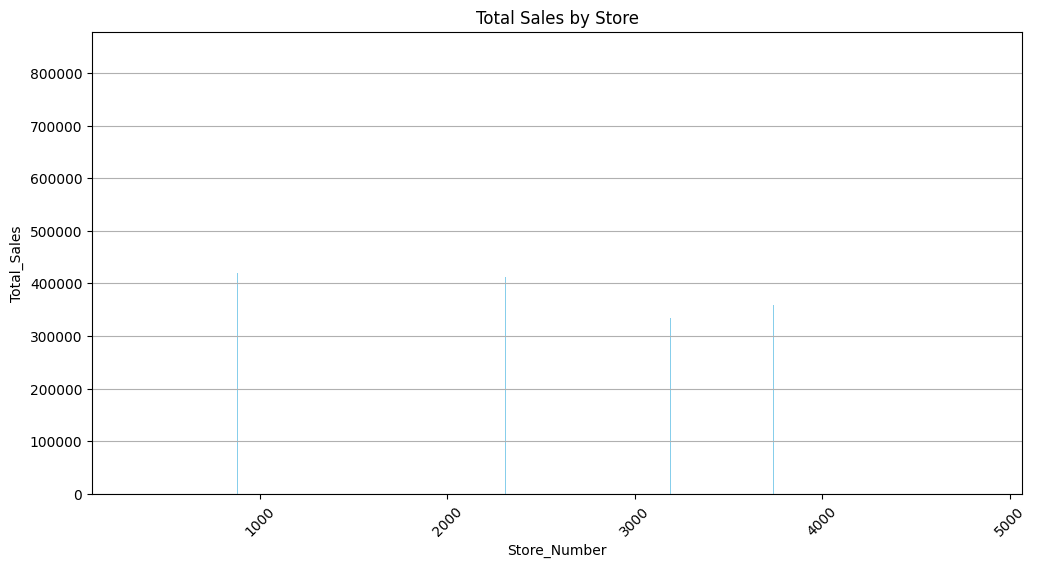

In [19]:
code_gen_df["label"] = code_gen_df["generated_code"].apply(code_is_runnable).map({True: "runnable", False: "not_runnable"})
code_gen_df["score"] = code_gen_df["label"].map({"runnable": 1, "not_runnable": 0})


In [20]:
code_gen_df.head()

,generated_code,label,score
context.span_id,,,
2b551149461c8058,import pandas as pd\nimport matplotlib.pyplot ...,runnable,1


In [21]:
px.Client().log_evaluations(
    SpanEvaluations(eval_name="Runnable Code Eval", dataframe=code_gen_df),
)

## Evaluating Analysis Clarity (Tool 2 - Data Analysis Evals)

In [22]:
CLARITY_LLM_JUDGE_PROMPT = """
In this task, you will be presented with a query and an answer. Your objective is to evaluate the clarity 
of the answer in addressing the query. A clear response is one that is precise, coherent, and directly 
addresses the query without introducing unnecessary complexity or ambiguity. An unclear response is one 
that is vague, disorganized, or difficult to understand, even if it may be factually correct.

Your response should be a single word: either "clear" or "unclear," and it should not include any other 
text or characters. "clear" indicates that the answer is well-structured, easy to understand, and 
appropriately addresses the query. "unclear" indicates that some part of the response could be better 
structured or worded.
Please carefully consider the query and answer before determining your response.

After analyzing the query and the answer, you must write a detailed explanation of your reasoning to 
justify why you chose either "clear" or "unclear." Avoid stating the final label at the beginning of your 
explanation. Your reasoning should include specific points about how the answer does or does not meet the 
criteria for clarity.

[BEGIN DATA]
Query: {query}
Answer: {response}
[END DATA]
Please analyze the data carefully and provide an explanation followed by your response.

EXPLANATION: Provide your reasoning step by step, evaluating the clarity of the answer based on the query.
LABEL: "clear" or "unclear"
"""

In [25]:
query = SpanQuery().where(
    "span_kind=='AGENT'"
).select(
    response="output.value",
    query="input.value"
)

# The Phoenix Client can take this query and return the dataframe.
clarity_df = px.Client().query_spans(query, 
                                     project_name=PROJECT_NAME,
                                     timeout=None)

clarity_df.head()

,response,query
context.span_id,,
e0c8068179e9efcd,"{""code"": null, ""observed_trends"": null, ""natur...","[{""role"": ""user"", ""content"": ""What was the mos..."
64bc3394fe4b90cb,"{""code"": null, ""observed_trends"": null, ""natur...","[{""role"": ""user"", ""content"": ""What was the tot..."
8860e81867d74603,"{""code"": null, ""observed_trends"": null, ""natur...","[{""role"": ""user"", ""content"": ""Which store had ..."
aa97393767bec8c0,"{""code"": ""import pandas as pd\nimport matplotl...","[{""role"": ""user"", ""content"": ""Create a bar cha..."
f5215d32ba6a2e5f,"{""code"": null, ""observed_trends"": ""Approximate...","[{""role"": ""user"", ""content"": ""What percentage ..."


In [26]:
with suppress_tracing():
    clarity_eval = llm_classify(
        dataframe = clarity_df,
        template = CLARITY_LLM_JUDGE_PROMPT,
        rails = ['clear', 'unclear'],
        model=OpenAIModel(model="gpt-4o"),
        provide_explanation=True
    )

clarity_eval['score'] = clarity_eval.apply(lambda x: 1 if x['label']=='clear' else 0, axis=1)

clarity_eval.head()

llm_classify |██████████| 6/6 (100.0%) | ⏳ 00:06<00:00 |  1.00s/it


,label,explanation,exceptions,execution_status,execution_seconds,score
context.span_id,,,,,,
e0c8068179e9efcd,clear,The query asks for the most popular product SK...,[],COMPLETED,3.362561,1
64bc3394fe4b90cb,clear,The query asks for the total revenue across al...,[],COMPLETED,4.997684,1
8860e81867d74603,clear,The query asks for the store with the highest ...,[],COMPLETED,4.664349,1
aa97393767bec8c0,clear,The query asks for a bar chart showing total s...,[],COMPLETED,3.847268,1
f5215d32ba6a2e5f,clear,The query asks for the percentage of items sol...,[],COMPLETED,4.130522,1


In [27]:
px.Client().log_evaluations(
    SpanEvaluations(eval_name="Response Clarity", dataframe=clarity_eval),
)

## Evaluating SQL Code Generation (Tool 1 - Database Lookup Evals)

In [28]:
SQL_EVAL_GEN_PROMPT = """
SQL Evaluation Prompt:
-----------------------
You are tasked with determining if the SQL generated appropiately answers a given instruction
taking into account its generated query and response.

Data:
-----
- [Instruction]: {question}
  This section contains the specific task or problem that the sql query is intended to solve.

- [Reference Query]: {query_gen}
  This is the sql query submitted for evaluation. Analyze it in the context of the provided
  instruction.

Evaluation:
-----------
Your response should be a single word: either "correct" or "incorrect".
You must assume that the db exists and that columns are appropiately named.
You must take into account the response as additional information to determine the correctness.

- "correct" indicates that the sql query correctly solves the instruction.
- "incorrect" indicates that the sql query correctly does not solve the instruction correctly.

Note: Your response should contain only the word "correct" or "incorrect" with no additional text
or characters.
"""

In [ ]:
query = SpanQuery().where(
    "span_kind=='LLM'"
).select(
    query_gen="llm.output_messages",
    question="input.value",
)

# The Phoenix Client can take this query and return the dataframe.
sql_df = px.Client().query_spans(query, 
                                 project_name=PROJECT_NAME,
                                 timeout=None)
sql_df = sql_df[sql_df["question"].str.contains("The SQL query to execute", na=False)]


['{"messages": [{"role": "user", "content": "\\nThe prompt is: What was the most popular product SKU?\\nThe available columns are: Index([\'Store_Number\', \'SKU_Coded\', \'Product_Class_Code\', \'Sold_Date\',\\n       \'Qty_Sold\', \'Total_Sale_Value\', \'On_Promo\'],\\n      dtype=\'object\')\\nThe table name is: sales\\n"}], "model": "gpt-4o-mini", "tool_choice": {"type": "function", "function": {"name": "SQLQuery"}}, "tools": [{"type": "function", "function": {"name": "SQLQuery", "description": "Correctly extracted `SQLQuery` with all the required parameters with correct types", "parameters": {"properties": {"query": {"description": "The SQL query to execute", "title": "Query", "type": "string"}}, "required": ["query"], "type": "object"}}}]}',
 '{"messages": [{"role": "user", "content": "\\nThe prompt is: What was the total revenue across all stores?\\nThe available columns are: Index([\'Store_Number\', \'SKU_Coded\', \'Product_Class_Code\', \'Sold_Date\',\\n       \'Qty_Sold\', \'

In [ ]:

sql_df["question"].to_list()

In [34]:
with suppress_tracing():
    sql_gen_eval = llm_classify(
        dataframe = sql_df,
        template = SQL_EVAL_GEN_PROMPT,
        rails = ['correct', 'incorrect'],
        model=OpenAIModel(model="gpt-4o"),
        provide_explanation=True
    )

sql_gen_eval['score'] = sql_gen_eval.apply(lambda x: 1 if x['label']=='correct' else 0, axis=1)

sql_gen_eval.head()

llm_classify |██████████| 8/8 (100.0%) | ⏳ 00:04<00:00 |  1.93it/s


,label,explanation,exceptions,execution_status,execution_seconds,score
context.span_id,,,,,,
57a86c20d09b972b,correct,The query provided is designed to find the mos...,[],COMPLETED,3.016426,1
1c34dce496791783,correct,The instruction asks for the total revenue acr...,[],COMPLETED,2.853421,1
565d17133f47f9da,correct,The SQL query correctly calculates the total s...,[],COMPLETED,2.065204,1
88d689950a4fc592,correct,The SQL query provided is: SELECT Store_Number...,[],COMPLETED,3.147097,1
ff51b46f0058a543,correct,The SQL query provided calculates the percenta...,[],COMPLETED,3.132180,1


In [35]:
px.Client().log_evaluations(
    SpanEvaluations(eval_name="SQL Gen Eval", dataframe=sql_gen_eval),
)